In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/True.csv
/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/Fake.csv


## Load Dataset + Basic check

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re 
# regular expression moduler - used for pattern based text cleaning and manipulation
# for example - Remove punctuation, Extract patterns (emails, urls)

import nltk
# python library for Natural Language Processing(NLP) Toolkit
# for example - Tokenization, stopword removal etc

from nltk.corpus import stopwords
# download stopwords dataset
# Stopwords = words that appear frequently but don’t help distinguish meaning
# for example - the is in and a to of for



nltk.download('stopwords')

print('Setup Complete')

Setup Complete


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
true = pd.read_csv('/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/True.csv')
fake = pd.read_csv('/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/Fake.csv')

In [4]:
fake.head()
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
# add label false and  true
fake['label']=0
true['label']=1

In [6]:
df = pd.concat([fake, true], ignore_index=True)
print(df.shape)

(44898, 5)


In [7]:
df['full_text'] = df['title'].fillna('')+" "+ df['text']
df = df[['full_text', 'label']].copy()

In [8]:
print(df.sample(3))
print(df.shape)
print(df['label'].value_counts())

                                               full_text  label
28673  White House aides told to preserve materials i...      1
22016  Boiler Room EP #124 – Weather Warfare & CNN Go...      0
41925  Britain is ready to walk away with no deal on ...      1
(44898, 2)
label
0    23481
1    21417
Name: count, dtype: int64


In [9]:
print(df.iloc[27603]['full_text'])

Trump's 'big announcement' on tax to be broad principles: official WASHINGTON (Reuters) - President Donald Trump’s promised “big announcement” next week on overhauling the U.S. tax code, a top campaign pledge, will consist of “broad principles and priorities,” an administration official said on Saturday. The president unexpectedly said on Friday at a Treasury Department event that there would be “a big announcement on Wednesday having to do with tax reform.” In a Twitter message on Saturday, he wrote: “Big TAX REFORM AND TAX REDUCTION will be announced next Wednesday.” Asked for details, the administration official, who asked not to be identified, said, “We will outline our broad principles and priorities” on Wednesday. Trump has struggled as president to advance his domestic policy agenda, including on taxes, even though his Republican Party controls both chambers of Congress. With his 100th day in office only a week away, he has yet to offer any formal legislation or win passage of a

In [10]:
# check any missing or null
df.isnull().sum()

full_text    0
label        0
dtype: int64

## Preprocessing (remove all stopwords)

In [11]:
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [12]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text) # Only letter + space
    words = text.split() # space wise splited
    words = [w for w in words if w not in  stop_words]
    return ' '.join(words)

In [13]:
df['new_clean_text'] = df['full_text'].apply(clean_text)

In [14]:
df[['full_text', 'new_clean_text', 'label']].sample(3)

,full_text,new_clean_text,label
23993,Official in charge of State Department reorgan...,official charge state department reorganizatio...,1
32916,U.S. justices rule against Virginia Republican...,us justices rule virginia republicans black vo...,1
6462,Republicans Sue Federal Government For ‘Right...,republicans sue federal government right discr...,0


Remove all stop words by using clean_text functions

## TF-IDF Vectorization and train/test split


#### TfidfVectorizer - converts text into numbers
#### train_test_split - splits data into training and testing set
#### TF-IDF = Term Frequency X Inverse Document Frequency

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [16]:
vectorizer = TfidfVectorizer(max_features=10000, # light and fast
                             ngram_range=(1,3), # bigrams
                             min_df=3)
X = vectorizer.fit_transform(df['new_clean_text'])
y = df['label']

In [17]:
X_train, X_test, y_train,  y_test = train_test_split(X, y, test_size=0.2,  random_state=42, stratify=y)

In [18]:
print("Train shape: ", X_train.shape)
print("Test shape: ", X_test.shape)

Train shape:  (35918, 10000)
Test shape:  (8980, 10000)


##  Train Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [20]:
model = LogisticRegression(max_iter=1000, C=5.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [21]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Fake", "Real"]))

Accuracy: 0.9951

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.99      1.00      4696
        Real       0.99      1.00      0.99      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



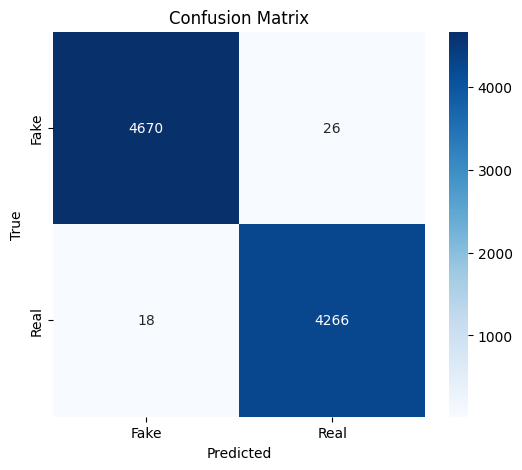

In [22]:
# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Fake", "Real"],  yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [23]:
def predict_news(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    prob = model.predict_proba(vec)[0]
    pred = model.predict(vec)[0]

    label = "Real" if pred==1 else "Fake"
    confidence = prob[pred]*100

    if pred == 1:
        return f"Real (confidence: {confidence:.1f}%)"
    else:
        return f"Fake (confidence: {confidence:.1f}%)"

In [24]:
print(predict_news("The Earth is flat and NASA is lying to everyone."))

Fake (confidence: 97.8%)


In [25]:
print(predict_news("Scientists discover new exoplanet with potential signs of life in 2025."))

Fake (confidence: 75.8%)


In [26]:
print(predict_news("The Earth is actually flat and NASA has been lying to the public for decades with fake space images and staged moon landings to hide the truth from humanity."))

Fake (confidence: 98.7%)


In [27]:
print(predict_news("""President Donald Trump threatened Nato allies over the weekend in a bid to secure help reopening the Straight of Hormuz.The effort failed, but instead of shifting gears the president stepped up his rhetoric earlier as the US searches for ways to calm oil and gas markets roiled by the war in Iran.In extended Oval Office remarks, Trump repeated his frustration with Nato, saying members of the alliance were "making a foolish mistake" by refusing to help the US secure the Straight of Hormuz.Iran has targeted commercial vessels in the waterway and brought oil exports to a near halt since the US-Israel war started last month.Trump singled out French President Emmanuel Macron and UK Prime Minister Keir Starmer. The British leader is "no Winston Churchill", Trump said, a line he's used repeatedly in recent weeks.How that line of attack will help Trump get the help he needs in Iran is an open question. The strategy could prove counterproductive and push allies away, leaving the US and Israel further isolated in their war with Iran.So far Trump has made little effort to build international consensus for the war, and allies have made clear they don't want to be drawn into the conflict.Trump insisted Tuesday that he doesn't need Nato's assistance. "We don't need any help," he said. If he continues criticizing Nato allies, he may not get it."""))

Real (confidence: 93.5%)


In [28]:
print(confusion_matrix(y_test, y_pred))

[[4670   26]
 [  18 4266]]


In [29]:
train_pred = model.predict(X_train)

from sklearn.metrics import accuracy_score
print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_pred))

Train Accuracy: 0.9978562280750598
Test Accuracy : 0.9951002227171493


In [30]:
print(df['new_clean_text'].duplicated().sum())

5821
